In [53]:
import math
import torch
import gpytorch
from matplotlib import pyplot as plt
import h5py
import numpy as np  
import random
import bacco
from bacco.halo import virial_mass_converter, virial_concentration_converter
from scipy import interpolate

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import emcee
import corner

In [3]:
bacco.configuration.config['growth']['method']='reps'

In [4]:
import os
os.chdir("/cosmos_storage/home/fgmaion/MTNG-resims/src")
import utils

In [5]:
plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"

### Get Parameters

In [23]:
wind_en_or      = []
wind_vel_or     = []
rho_rec_or      = []
sf_ts_or        = []
ef_kin_or       = []
ef_high_or      = []
f_re_or         = []

for i in range(31):
    if i<30:
        filename = "/cosmos_storage/simulations/TNG_Family/MN5_resims/param_LH/param_MTNG-hydro_{:d}.txt".format(i)
    else:
        filename = "/cosmos_storage/simulations/TNG_Family/MN5_resims/param_LH/param_MTNG-hydro.txt"

    with open(filename, 'r') as f:
        for line in f.readlines():
            if len(line.split())!=0:
                if line.split()[0] == 'WindEnergyIn1e51erg':
                    wind_en_or.append(float(line.split()[1]))
                if line.split()[0] == 'VariableWindVelFactor':
                    wind_vel_or.append(float(line.split()[1]))
                if line.split()[0] == 'WindFreeTravelDensFac':
                    rho_rec_or.append(float(line.split()[1]))
                if line.split()[0] == 'MaxSfrTimescale':
                    sf_ts_or.append(float(line.split()[1]))
                if line.split()[0] == 'RadioFeedbackFactor':
                    ef_kin_or.append(float(line.split()[1]))
                if line.split()[0] == 'BlackHoleFeedbackFactor':
                    ef_high_or.append(float(line.split()[1]))
                if line.split()[0] == 'RadioFeedbackReiorientationFactor':
                    f_re_or.append(float(line.split()[1]))

rho_rec_or = np.log10(rho_rec_or)
ef_kin_or = np.log10(ef_kin_or)

wind_en   = (np.asarray(wind_en_or) - np.mean(wind_en_or)) / np.std(wind_en_or)
wind_vel  = (np.asarray(wind_vel_or) - np.mean(wind_vel_or)) / np.std(wind_vel_or)
rho_rec   = (np.asarray(rho_rec_or) - np.mean(rho_rec_or)) / np.std(rho_rec_or)
sf_ts     = (np.asarray(sf_ts_or) - np.mean(sf_ts_or)) / np.std(sf_ts_or)
ef_kin    = (np.asarray(ef_kin_or) - np.mean(ef_kin_or)) / np.std(ef_kin_or)
ef_high   = (np.asarray(ef_high_or) - np.mean(ef_high_or)) / np.std(ef_high_or)
f_re      = (np.asarray(f_re_or) - np.mean(f_re_or)) / np.std(f_re_or)

In [24]:
def pars(i, m500):

    arr = np.vstack( (m500, np.ones(len(m500)) * wind_en[i],\
                        np.ones(len(m500)) * wind_vel[i],\
                        np.ones(len(m500)) * rho_rec[i],\
                        np.ones(len(m500)) * sf_ts[i],\
                        np.ones(len(m500)) * ef_kin[i],\
                        np.ones(len(m500)) * ef_high[i],\
                        np.ones(len(m500)) * f_re[i])).T

    return arr

In [60]:
name_list = ['LH_{:d}'.format(i) for i in range(30)] + ['fiducial']

In [50]:
fid_pars = np.array([wind_en[30], wind_vel[30], rho_rec[30], sf_ts[30], ef_kin[30], ef_high[30], f_re[30]])

weights = (0.1, 1, 0.1, 1, 0.1, 0.1, 0.1)

dist = np.zeros(31)
for i in range(len(name_list)):
    pars_i = np.array([wind_en[i], wind_vel[i], rho_rec[i], sf_ts[i], ef_kin[i], ef_high[i], f_re[i]])
    dist[i] = np.sum((weights*(pars_i - fid_pars))**2)

#### Load the MTNG

In [51]:
mtng = bacco.utils.load_MTNG(adr="/cosmos_storage/simulations/TNG_Family/MTNG/", snap=264)

2026-01-27 01:21:09,473 bacco.sims : Initialising simulation Default
2026-01-27 01:21:09,475 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MTNG/groups_264/fof_subhalo_tab_264
2026-01-27 01:21:09,477 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MTNG/groups_264/fof_subhalo_tab_264
2026-01-27 01:21:09,511 bacco.sims : ...done in 0.0105 s


### Load the Zooms

In [52]:
sigma8 = 0.8159 #CHECK ME
ns     = 0.9667 #CHECK ME
tau    = 0.0965 #CHECK ME

snap = 264
zoom = {}

loaded = []
for i in range(len(name_list)):
    if i<30:
        base = "/cosmos_storage/simulations/TNG_Family/MN5_resims/LH_{:d}/hydro_output/".format(i)
    else:
        base = "/cosmos_storage/simulations/TNG_Family/MN5_resims/fiducial/hydro_output/"
    zoom[name_list[i]] = bacco.Simulation(basedir=base, halo_file="groups_{:03d}/fof_subhalo_tab_{:03d}".format(snap,snap), sim_format='TNG500', fixedPk=True, use_orphans=False,\
                            tau=tau, ns=ns, sigma8=sigma8, tree_file="groups_{:03d}/subhalo_prog_{:03d}".format(snap,snap), use_ids=True, numpart=4320)


2026-01-27 01:21:10,673 bacco.sims : Initialising simulation Default
2026-01-27 01:21:10,674 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_0/hydro_output/groups_264/fof_subhalo_tab_264
2026-01-27 01:21:10,676 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_0/hydro_output/groups_264/fof_subhalo_tab_264


2026-01-27 01:21:11,108 bacco.sims : ...done in 0.00592 s
2026-01-27 01:21:11,109 bacco.sims : Initialising simulation Default
2026-01-27 01:21:11,110 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_1/hydro_output/groups_264/fof_subhalo_tab_264
2026-01-27 01:21:11,112 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_1/hydro_output/groups_264/fof_subhalo_tab_264
2026-01-27 01:21:11,545 bacco.sims : ...done in 0.00587 s
2026-01-27 01:21:11,546 bacco.sims : Initialising simulation Default
2026-01-27 01:21:11,546 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_2/hydro_output/groups_264/fof_subhalo_tab_264
2026-01-27 01:21:11,548 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_2/hydro_output/groups_264/fof_subhalo_tab_264
2026-01-27 01:21:11,552 bacco.sims : ...done in 0.00497 s
2026-01-27 01:21:11,553 bacco.sims : Initialising simulation Default
2026-01-27 01:21:11,553 bacco.sims : try /cosmos_st

In [53]:
Nbins_fgas = 8

zoom_fgas = {}
for i in range(len(name_list)):
    zoom_fgas[name_list[i]] = np.load("/cosmos_storage/home/fgmaion/MTNG-resims/results/fgas/fgas_{}_Nbins{:d}.npy".format(name_list[i], Nbins_fgas), allow_pickle=True)[0]

Text(0, 0.5, '$f_{gas}$')

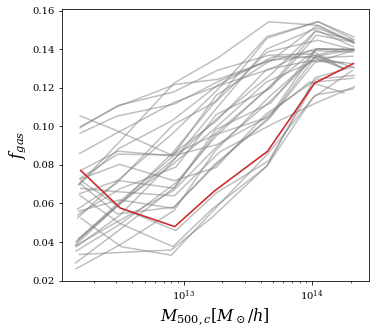

In [54]:
fig, ax = plt.subplots(1,1, figsize=(5.5,5))

ax.set_xscale('log')
ax.set_yscale('linear')

for i in range(len(name_list)):
    ax.plot(zoom_fgas[name_list[i]]['m500c'][0], zoom_fgas[name_list[i]]['f_gas'][0], color='gray', alpha=0.5)

ax.plot(zoom_fgas['fiducial']['m500c'][0], zoom_fgas['fiducial']['f_gas'][0], color='C3')

ax.set_xlabel(r"$M_{500,c} [M_\odot/h]$", fontsize=16)
ax.set_ylabel(r"$f_{gas}$", fontsize=16)

In [55]:
train_sel = np.argsort(dist)[::-1][:25]
test_sel = list(set(range(31)) - set(train_sel))

In [56]:
#del smf_global, arr_global
pars_global = pars(train_sel[0], np.log10(zoom_fgas[name_list[train_sel[0]]]['m500c'][0]))
fgas_global = zoom_fgas[name_list[train_sel[0]]]['f_gas'][0]

for i in range(len(train_sel)):
    m500c = np.log10(zoom_fgas[name_list[train_sel[i]]]['m500c'][0])

    arr = pars(train_sel[i], m500c)

    pars_global = np.vstack((pars_global, arr))

    fgas_global = np.hstack((fgas_global, zoom_fgas[name_list[train_sel[i]]]['f_gas'][0]))

In [57]:
train_x = torch.asarray(pars_global, dtype=torch.float)
train_y = torch.asarray(fgas_global, dtype=torch.float)

In [58]:
torch.set_num_threads(8)

### Build the GP Model

In [59]:
# We will use the simplest form of GP model, exact inference
class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(ExactGPModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel(ard_num_dims=8))

    def initialize(self):
        # reset constant mean to something reasonable
        self.mean_module.constant.data.normal_(0, 0.1)

        # lengthscales (ARD) :
        # initialize in log-space so we get spread over ~[0.3, 3] in standardized units
        with torch.no_grad():
            ls = 0.5 + torch.rand_like(self.covar_module.base_kernel.lengthscale)
            self.covar_module.base_kernel.lengthscale.copy_(ls)

        # reset outputscale
        self.covar_module.outputscale = 1.0

        # reset likelihood noise to moderate value
        self.likelihood.noise = 1e-4

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# initialize likelihood and model
likelihood = gpytorch.likelihoods.GaussianLikelihood(noise_constraint=gpytorch.constraints.GreaterThan(1e-6))
model = ExactGPModel(train_x, train_y, likelihood)

In [60]:
# # We will use the simplest form of GP model, exact inference
# class SpectralMixtureGPModel(gpytorch.models.ExactGP):
#     def __init__(self, train_x, train_y, likelihood):
#         super(SpectralMixtureGPModel, self).__init__(train_x, train_y, likelihood)
#         self.mean_module = gpytorch.means.ConstantMean()
#         self.covar_module = gpytorch.kernels.SpectralMixtureKernel(num_mixtures=4)
#         #self.covar_module.initialize_from_data(train_x, train_y)

#     def forward(self, x):
#         mean_x = self.mean_module(x)
#         covar_x = self.covar_module(x)
#         return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# # initialize likelihood and model
# likelihood = gpytorch.likelihoods.GaussianLikelihood()
# model = SpectralMixtureGPModel(train_x, train_y, likelihood)

#### Train it

In [61]:
# this is for running the notebook in our testing framework
import os
import copy
smoke_test = ('CI' in os.environ)
#training_iter = 2 if smoke_test else 200

n_restarts = 200
steps_per_restart = 20

best_state = None
best_loss = float('inf')

for r in range(n_restarts):
    print(f"\n=== Restart {r+1}/{n_restarts} ===")
    model.initialize()

    # Find optimal model hyperparameters
    model.train()
    likelihood.train()

    # Use the adam optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)  # Includes GaussianLikelihood parameters

    # "Loss" for GPs - the marginal log likelihood
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    for i in range(steps_per_restart):
        # Zero gradients from previous iteration
        optimizer.zero_grad()
        # Output from model
        output = model(train_x)
        # Calc loss and backprop gradients
        loss = -torch.sum(mll(output, train_y))
        loss.backward()
        optimizer.step()

    # compute final loss for this restart
    with torch.no_grad():
        final_output = model(train_x)
        final_loss = float(-mll(final_output, train_y))

    print(f"Final loss restart {r+1}: {final_loss:.4f}")

    # store best
    if final_loss < best_loss:
        best_loss = final_loss
        best_state = {
            'model': copy.deepcopy(model.state_dict()),
            'likelihood': copy.deepcopy(likelihood.state_dict()),
        }


=== Restart 1/200 ===
Final loss restart 1: -0.7181

=== Restart 2/200 ===
Final loss restart 2: -0.9233

=== Restart 3/200 ===
Final loss restart 3: -1.1057

=== Restart 4/200 ===


Final loss restart 4: -1.2664

=== Restart 5/200 ===
Final loss restart 5: -1.4094

=== Restart 6/200 ===
Final loss restart 6: -1.5387

=== Restart 7/200 ===
Final loss restart 7: -1.6556

=== Restart 8/200 ===
Final loss restart 8: -1.7613

=== Restart 9/200 ===
Final loss restart 9: -1.8575

=== Restart 10/200 ===
Final loss restart 10: -1.9454

=== Restart 11/200 ===
Final loss restart 11: -2.0254

=== Restart 12/200 ===
Final loss restart 12: -2.0979

=== Restart 13/200 ===
Final loss restart 13: -2.1637

=== Restart 14/200 ===
Final loss restart 14: -2.2231

=== Restart 15/200 ===
Final loss restart 15: -2.2768

=== Restart 16/200 ===
Final loss restart 16: -2.3250

=== Restart 17/200 ===
Final loss restart 17: -2.3681

=== Restart 18/200 ===
Final loss restart 18: -2.4067

=== Restart 19/200 ===
Final loss restart 19: -2.4404

=== Restart 20/200 ===
Final loss restart 20: -2.4701

=== Restart 21/200 ===
Final loss restart 21: -2.4961

=== Restart 22/200 ===
Final loss restart 22

In [63]:
print(model.covar_module.base_kernel.lengthscale)
print(model.covar_module.outputscale)
print(torch.sqrt(model.likelihood.noise_covar.noise))

tensor([[ 2.6030, 15.8520, 12.0810, 33.5960, 39.5098, 32.4397, 39.9110, 39.9264]],
       grad_fn=<SoftplusBackward0>)
tensor(0.8804, grad_fn=<SoftplusBackward0>)
tensor([0.0091], grad_fn=<SqrtBackward0>)


In [26]:
# Get into evaluation (predictive posterior) mode
model.eval()
likelihood.eval()

# # Test points are regularly spaced along [0,1]
# # Make predictions by feeding model through likelihood
# with torch.no_grad(), gpytorch.settings.fast_pred_var():
#     #smf_test = model(mstar_test)
#     observed_pred1 = likelihood(model(torch.asarray(test_x1, dtype=torch.float)))

GaussianLikelihood(
  (noise_covar): HomoskedasticNoise(
    (raw_noise_constraint): GreaterThan(1.000E-06)
  )
)

In [27]:
########################################### baseline  ###########################################################
rebin = False

load_backup = False

cosmo_pars = {
    'omega_matter'  :  0.313,
    'sigma8_cold'   :  0.7482562639166517,
    'omega_baryon'  :  0.0493,
    'ns'            :  0.9649,
    'hubble'        :  0.6727,
    'neutrino_mass' :  93.14*0.00083,
    'w0'            : -1.0,
    'wa'            :  0.0,
    'expfactor'     :  1
    }

baryon_pars ={
    'M_c'           :  14.50053485105879,
    'eta'           : -0.24780202578955512,
    'beta'          : 0.32142878904178573,
    'M1_z0_cen'     : 10.405343976915722,
    'theta_out'     : 0.41894250174563846,
    'theta_inn'     : -0.7024015776841996,
    'M_inn'         : 13.041810858810035
}

params = {**cosmo_pars, **baryon_pars}
baseline_pars = copy.deepcopy(params)
cosmo_pars['omega_cdm'] = cosmo_pars['omega_matter'] - cosmo_pars['omega_baryon'] - cosmo_pars['neutrino_mass'] / 93.14 / cosmo_pars['hubble']**2
del cosmo_pars['omega_matter']
cosmo_pars['sigma8'] = cosmo_pars['sigma8_cold']
del cosmo_pars['sigma8_cold']

cosmo = bacco.Cosmology(**cosmo_pars)

#M_c:     68%: +0.62, -0.37 95%: 13.2
#Omega_m: 68%:  +0.025, -0.016 95%: +0.038 -0.045

#X-ray: M_c = 13.5   12.86, 14.3

pars_68_minus = copy.deepcopy(params)
pars_68_plus = copy.deepcopy(params)
pars_68_minus['M_c'] -= 0.37
pars_68_plus['M_c'] += 0.62

pars_95_minus = copy.deepcopy(params)
pars_95_plus = copy.deepcopy(params)
pars_95_minus['M_c'] = 13.2
pars_95_plus['M_c'] = 15

######################## load DES y3 chains with BACCOemu - baseline



###############################################################################################################


data_dir = '/cosmos_storage/home/fgmaion/'

#WANING: Cosmology dependence of the measurements??? on Universl Baryon fraction
##### Gonzalez
data = np.loadtxt(data_dir+'gas_fractions/data/Gonzalez_2013.dat',skiprows=1)
f_gas = data[:,1] * 0.6715**(3/2)/(params['hubble']**(3/2))
erf_gas = data[:,2] * 0.6715**(3/2)/(params['hubble']**(3/2))
f_star = data[:,3]
erf_star = data[:,4]
m500 = data[:,7]*1e14*0.6715#Hubble factor assumed in the paper
erm500 = data[:,8]*1e14*0.6715
r500 = data[:,9]*0.6715
err500 = data[:,10]*0.6715

r200=virial_concentration_converter(500,r500,200)
m200 = virial_mass_converter(500,m500,r500,200,r200)

####### Vikhlinin
data = np.loadtxt(data_dir+'gas_fractions/data/Vikhlinin_2006.dat',skiprows=2)
f_gas_V = data[:,14] * 0.72**(3/2)/(params['hubble']**(3/2))
erf_gas_V = data[:,15] * 0.72**(3/2)/(params['hubble']**(3/2))
m500_V = data[:,10]*1e14 * 0.72#Hubble factor assumed in the paper
erm500_V = data[:,11]*1e14 * 0.72
r500_V = data[:,0] * 0.72
err500_V = data[:,1] * 0.72

####### Giodini 2009
data = np.loadtxt(data_dir+'gas_fractions/data/Giodini_2009.dat',skiprows=2)
f_star_G = data[:,1]
erf_star_G = data[:,2]
m500_G = data[:,0] * 0.72#Hubble factor assumed in the paper
f_gas_G = data[:,3] * 0.72**(3/2)/(params['hubble']**(3/2))
erf_gas_G = data[:,4] * 0.72**(3/2)/(params['hubble']**(3/2))
f_stargas_G = data[:,5]
erf_stargas_G = data[:,6]

####### Arnaud 2017
data = np.loadtxt(data_dir+'gas_fractions/data/Arnaud_2007.dat',skiprows=2)

m500_A = data[:,4] *0.7*1e14
m500_Ap = data[:,5] *0.7*1e14
m500_Am = -data[:,6] *0.7*1e14
f_gas_A = data[:,13] * 0.7**(3/2)/(params['hubble']**(3/2))
f_gas_Ap = data[:,14] * 0.7**(3/2)/(params['hubble']**(3/2))
f_gas_Am = -data[:,15] * 0.7**(3/2)/(params['hubble']**(3/2))

##########################################

####### Sun 2008
data = np.loadtxt(data_dir+'gas_fractions/data/Sun_2008.dat',skiprows=2)

m500_S = data[:,1]*0.73*1e13
m500_Sp = data[:,2]*0.73*1e13
m500_Sm = -data[:,3]*0.73*1e13
f_gas_S = data[:,4]* 0.73**(3/2)/(params['hubble']**(3/2))
f_gas_Sp = data[:,5]* 0.73**(3/2)/(params['hubble']**(3/2))
f_gas_Sm = -data[:,6]* 0.73**(3/2)/(params['hubble']**(3/2))

##########################################

baccom200 = np.logspace(11, np.log10(6e15), 100)
baccoconc200 = cosmo.compute_concentration(baccom200)
baccoconc500 =  virial_concentration_converter(200,baccoconc200,500)
baccom500 = virial_mass_converter(200,baccom200,baccoconc200,500,baccoconc500)


data_ff = np.concatenate( (f_gas_V, f_gas_S, f_gas_G, f_gas, f_gas_A) )
data_m500 = np.concatenate( (m500_V, m500_S, m500_G, m500, m500_A) )
data_m200 = np.exp(np.interp(np.log(data_m500), np.log(baccom500), np.log(baccom200)))
data_std = np.concatenate( (erf_gas_V, 0.5*(f_gas_Sm+f_gas_Sp), erf_gas_G, erf_gas, 0.5*(f_gas_Am+f_gas_Ap)) )

if rebin:
    nbins = 6

    from scipy import stats
    ff_rebinned, _, c = stats.binned_statistic(np.log10(data_m200), data_ff, bins=nbins, statistic='mean')
    std_rebinned, _, c = stats.binned_statistic(np.log10(data_m200), data_ff, bins=nbins, statistic='std')
    err_rebinned, _, c = stats.binned_statistic(np.log10(data_m200), data_std**2, bins=nbins, statistic='mean')
    count, _, c = stats.binned_statistic(np.log10(data_m200), data_std**2, bins=nbins, statistic='count')
    err_rebinned = np.sqrt(err_rebinned/count)

    m200_rebinned, _, c = stats.binned_statistic(np.log10(data_m200), data_m200, bins=nbins, statistic='mean')
    m500_rebinned = np.exp(np.interp(np.log(m200_rebinned), np.log(baccom200), np.log(baccom500)))

    #std_rebinned =  np.sqrt(err_rebinned**2 +std_rebinned**2)

    data_ff = ff_rebinned
    data_m500 = m500_rebinned
    data_m200 = m200_rebinned
    data_std = std_rebinned

if_rebin = '_rebinned' if rebin else ''


bounds = [[12, 15],[-1,1], [0.14,0.45], [0.04,0.06], [0.10,0.5]]

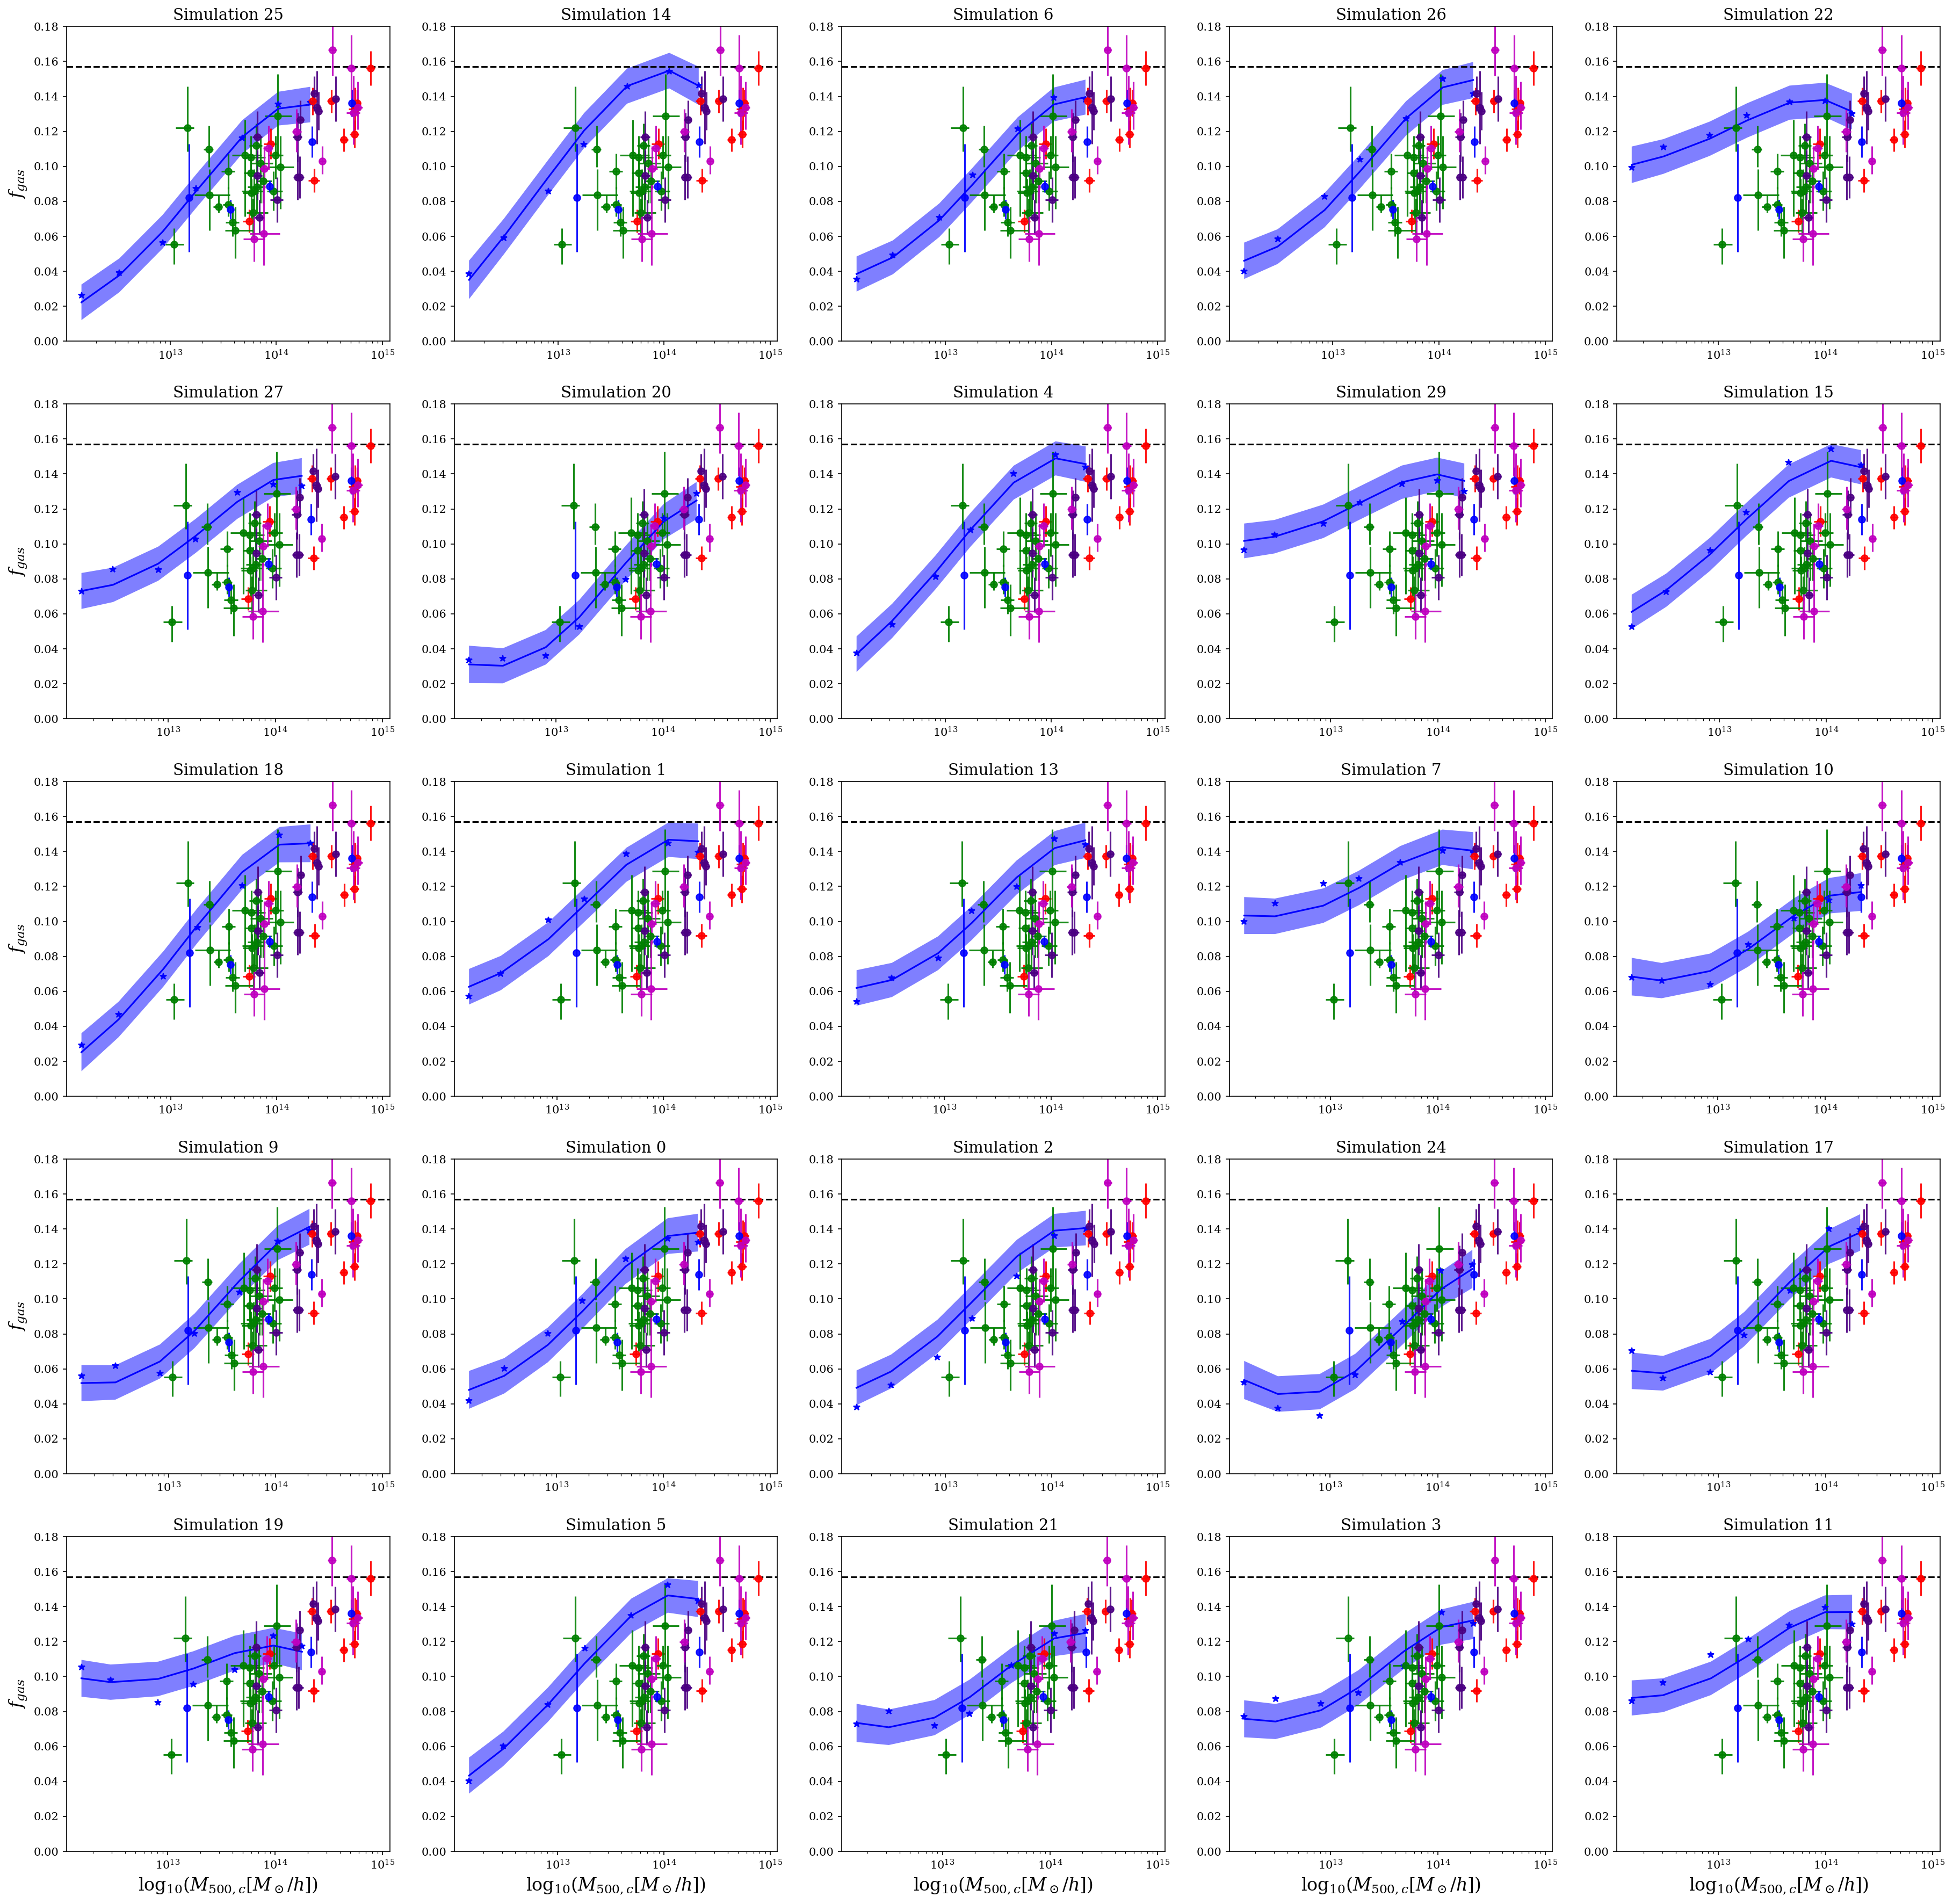

In [28]:
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    # Initialize plot
    f, ax = plt.subplots(5, 5, figsize=(30, 30), dpi=150)

    for i in range(5):
        for j in range(5):
            if j==0:
                ax[i,j].set_ylabel(r"$f_{gas}$", fontsize=16)
            if i==4:
                ax[i,j].set_xlabel(r"$\log_{10}(M_{500,c} [M_\odot/h])$", fontsize=16)

            ax[i,j].set_title("Simulation {}".format(train_sel[5*i+j]), fontsize=14)
            ax[i,j].set_ylim(0, 0.18)
            ax[i,j].set_xscale("log")
    
            ax[i,j].axhline(y=0.157, color='k', ls='--', alpha=1)

            ax[i,j].errorbar(m500_V,f_gas_V,yerr=erf_gas_V,xerr=erm500_V,marker='o',c='red',ls='',label='Vikhlinin et al. 2006',alpha=0.9)
            ax[i,j].errorbar(m500_S,f_gas_S,yerr=(f_gas_Sm,f_gas_Sp),xerr=(m500_Sm,m500_Sp),marker='o',c='g',ls='',label='Sun et al. 2008',alpha=0.9)
            ax[i,j].errorbar(m500_G,f_gas_G,yerr=erf_gas_G, marker='o',c='blue',ls='',label='Giodini et al. 2009',alpha=0.9)
            ax[i,j].errorbar(m500,f_gas,yerr=erf_gas,xerr=erm500,marker='o',c='indigo',ls='',label='Gonzalez et al. 2013',alpha=0.9)
            ax[i,j].errorbar(m500_A,f_gas_A,yerr=(f_gas_Am,f_gas_Ap),xerr=(m500_Am,m500_Ap),marker='o',c='m',ls='',label='Arnaud et al. 2017',alpha=0.9)

            test_x = torch.asarray(pars(train_sel[5*i+j], np.log10(zoom_fgas[name_list[train_sel[5*i+j]]]['m500c'][0])), dtype=torch.float)
            observed_pred = likelihood(model(torch.asarray(test_x, dtype=torch.float)))
        
            # Get upper and lower confidence bounds
            lower, upper = observed_pred.confidence_region()
            # Plot training data as black stars
            ax[i,j].plot(zoom_fgas[name_list[train_sel[5*i+j]]]['m500c'][0], zoom_fgas[name_list[train_sel[5*i+j]]]['f_gas'][0], 'b*')

            # Plot predictive means as blue line
        #    for i in range(10):
        #        ax.plot(mstar_test, smf_test.sample().numpy(), 'b', ls='--', lw=0.5)
            ax[i,j].plot(10**(test_x[:,0]), observed_pred.mean.numpy(), 'b')

            # Shade between the lower and upper confidence bounds
            ax[i,j].fill_between(10**(test_x[:,0].numpy()), observed_pred.mean.numpy()-observed_pred.stddev.numpy(), observed_pred.mean.numpy()+observed_pred.stddev.numpy(), color='b', alpha=0.5, edgecolor=None)

# ax.set_xlabel('$M_*$')
# ax.set_ylabel('SMF')


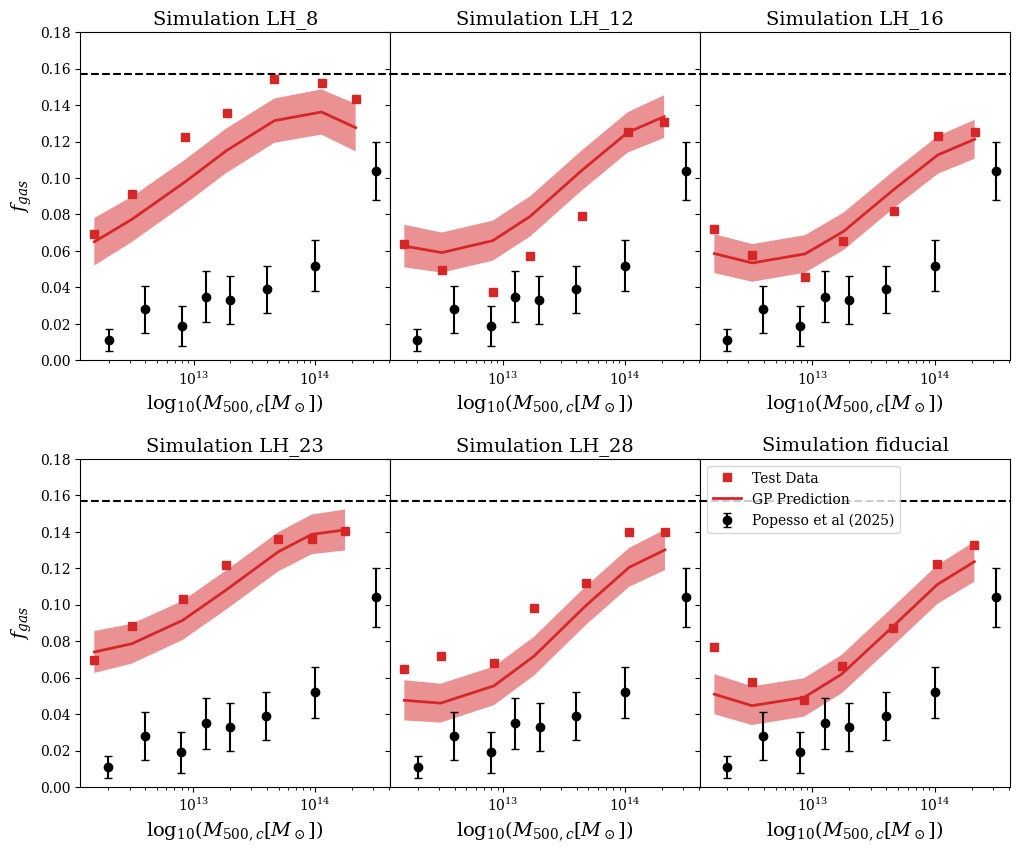

In [93]:
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    # Initialize plot
    f, ax = plt.subplots(2, 3, figsize=(12, 10), dpi=100, sharey=True)

    for i in range(2):
        for j in range(3):
            ax[i,j].set_xlabel("$\log_{10}(M_{500,c} [M_\odot])$", fontsize=14)
            if j==0:
                ax[i,j].set_ylabel(r"$f_{gas}$", fontsize=14)

            ax[i,j].set_ylim(0, 0.18)
            ax[i,j].axhline(y=0.157, color='k', ls='--', alpha=1)
            ax[i,j].set_xscale("log")
            ax[i,j].errorbar(
                10**(m500_pp), 
                fgas_pp, 
                yerr=err_pp, # Error bars show the observation uncertainty
                fmt='o', 
                color='k', 
                capsize=3, 
                zorder=3, # Bring to front
                label='Popesso et al (2025)'
                )

            ax[i,j].set_title("Simulation {}".format(name_list[test_sel[3*i+j]]), fontsize=14)

            test_x = torch.asarray(pars(test_sel[3*i+j], np.log10(zoom_fgas[name_list[test_sel[3*i+j]]]['m500c'][0])), dtype=torch.float)
            observed_pred = likelihood(model(torch.asarray(test_x, dtype=torch.float)))
        
            # Get upper and lower confidence bounds
            lower, upper = observed_pred.confidence_region()
            # Plot test data as black stars
            ax[i,j].plot(zoom_fgas[name_list[test_sel[3*i+j]]]['m500c'][0],
                        zoom_fgas[name_list[test_sel[3*i+j]]]['f_gas'][0],
                        color='C3',
                        marker='s',
                        ms=6,
                        ls='',
                        label='Test Data')

            ax[i,j].plot(10**(test_x[:,0]), observed_pred.mean.numpy(), 'C3', lw=2, label='GP Prediction')
            ax[i,j].fill_between(10**(test_x[:,0].numpy()), observed_pred.mean.numpy()-observed_pred.stddev.numpy(), observed_pred.mean.numpy()+observed_pred.stddev.numpy(), color='C3', alpha=0.5, edgecolor=None)

    plt.subplots_adjust(wspace=0, hspace=0.3)

ax[1,2].legend(loc='upper left', fontsize=10)

plt.savefig("/cosmos_storage/home/fgmaion/MTNG-resims/results/testing_plots/fgas_test.pdf", bbox_inches='tight')

##### Helper functions for evaluating GP

In [30]:
def prepare_theta(theta):

    theta_std = np.copy(theta)
    
    theta_std[0]  = (theta_std[0] - np.mean(wind_en_or)) / np.std(wind_en_or)
    theta_std[1]  = (theta_std[1] - np.mean(wind_vel_or)) / np.std(wind_vel_or)
    theta_std[2]  = (theta_std[2] - np.mean(rho_rec_or)) / np.std(rho_rec_or)
    theta_std[3]  = (theta_std[3] - np.mean(sf_ts_or)) / np.std(sf_ts_or)
    theta_std[4]  = (theta_std[4] - np.mean(ef_kin_or)) / np.std(ef_kin_or)
    theta_std[5]  = (theta_std[5] - np.mean(ef_high_or)) / np.std(ef_high_or)
    theta_std[6]  = (theta_std[6] - np.mean(f_re_or)) / np.std(f_re_or)

    return theta_std

lower_bound = np.asarray([0.9,  3.7,  np.log10(0.005), 0.001135, np.log10(0.001), 0.05, 10])
upper_bound = np.asarray([14.4, 14.8, np.log10(0.5),   0.00454,  np.log10(2),     0.2,  40 ])

def gp_eval(theta, m500, gp_model):

    theta_std = prepare_theta(theta)
    theta_vector = np.repeat(theta_std[np.newaxis, :], len(m500), axis=0) # (10, 7)

    # Full 8D input tensor
    gp_input = np.hstack([
        m500[:, np.newaxis],
        theta_vector
    ]) 

    # 3. Get the GP prediction for the full SMF curve
    x_eval = torch.from_numpy(gp_input).float() 
    
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        # Get predictive distribution for all mass bins simultaneously (N_mass_bins predictions)
        predictive_dist = gp_model(x_eval) 
        
    mu_pred = predictive_dist.mean.numpy() # (N_mass_bins,)
    var_emulator = predictive_dist.variance.numpy() # (N_mass_bins,)

    return mu_pred, var_emulator

##### Compare 1P-variation behaviour of GP to CAMELS

In [31]:
filename = "/scratch/fgmaion/CAMELS/1P/info.txt"

data_idx = np.array([3,5,16,10,4,25,6])

data = {}
with open(filename) as f:
    lines = f.readlines()
    for i in range(1,len(lines)):
        lines[i].strip()
        columns = [item.strip() for item in lines[i].split(',')]
        data[i] = {'Name':columns[0], 'AbsMaxDiff':float(columns[1]), 'LogFlag':int(columns[2]), 'FidVal':float(columns[3]), 'MinVal':float(columns[4]), 'MaxVal':float(columns[5]), 'Desc':columns[6]}

fgas = {}
for j in range(len(data_idx)):
    fgas[j] = {}    
    index = ['n2', 'n1', '0', '1', '2']
    for i in range(5):
        fgas[j][index[i]] = utils.camels_gas_frac(index[i], data_idx[j], nbins=10)

/lscratch/fgmaion/miniconda3/envs/condaenv/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/lscratch/fgmaion/miniconda3/envs/condaenv/lib/python3.9/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


In [32]:
fid_theta = np.asarray([wind_en_or[30], wind_vel_or[30], rho_rec_or[30], sf_ts_or[30], ef_kin_or[30], ef_high_or[30], f_re_or[30]])

print(lower_bound)
print(upper_bound)
print(fid_theta)

[ 9.00000e-01  3.70000e+00 -2.30103e+00  1.13500e-03 -3.00000e+00
  5.00000e-02  1.00000e+01]
[ 1.44000000e+01  1.48000000e+01 -3.01029996e-01  4.54000000e-03
  3.01029996e-01  2.00000000e-01  4.00000000e+01]
[ 3.60000e+00  7.40000e+00 -1.30103e+00  2.27000e-03  0.00000e+00
  1.00000e-01  2.00000e+01]


In [33]:
def get_theta_1p_vars(param_num, nvars):
    theta_1p_vars = {}

    delta = (upper_bound[param_num] - lower_bound[param_num]) / nvars

    for i in range(nvars+1):
        theta_1p_vars[i] = np.copy(fid_theta)
        
        theta_1p_vars[i][param_num] = fid_theta[param_num] + (i-2) * delta

    return theta_1p_vars

In [34]:
m500_pp = np.asarray([12.3,12.6,12.9,13.1,13.3,13.6,14.0,14.5])
fgas_pp = np.asarray([0.011,0.028,0.019,0.035,0.033,0.039,0.052,0.104])
err_pp = np.asarray([0.006,0.013,0.011,0.014,0.013,0.013,0.014,0.016])

m500 = m500_pp
obs_fgas = fgas_pp
obs_uncertainty = err_pp

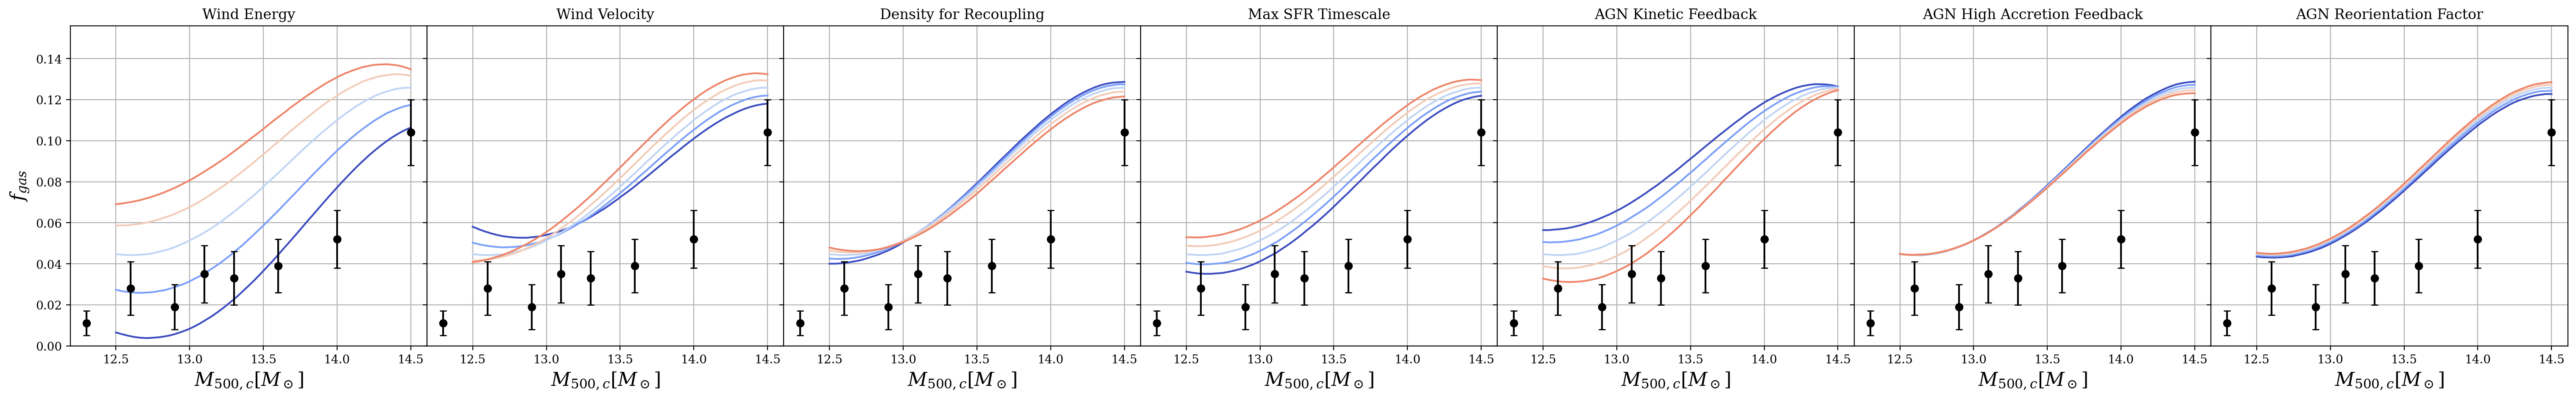

In [35]:
fig, ax = plt.subplots(1, 7, dpi=200, sharey=True, figsize=(38,5))

ax[0].set_ylabel(r"$f_{gas}$", fontsize=16)

cmap = plt.get_cmap('coolwarm')

m500_test = np.linspace(12.5,14.5,50)
names = ['Wind Energy', 'Wind Velocity', 'Density for Recoupling', 'Max SFR Timescale', 'AGN Kinetic Feedback', 'AGN High Accretion Feedback', 'AGN Reorientation Factor']

mu_fid, var_fid = gp_eval(fid_theta, m500_test, model)

for j in range(7):
    ax[j].set_title(names[j])
    ax[j].set_xlabel(r"$M_{500,c} [M_\odot]$", fontsize=16)
    theta_vars = get_theta_1p_vars(j, 5)

    for i in range(5):
        # Our measurements
        mu_pred, var = gp_eval(theta_vars[i], m500_test, model)
        ax[j].plot(m500_test, mu_pred, color=cmap(i/5))
    
    ax[j].grid()
 
    ax[j].errorbar(
    m500_pp, 
    fgas_pp, 
    yerr=err_pp, # Error bars show the observation uncertainty
    fmt='o', 
    color='k', 
    capsize=3, 
    zorder=3, # Bring to front
    label='Popesso et al (2025)'
    )

    ax[j].set_ylim(0, 0.156)

plt.subplots_adjust(wspace=0, hspace=0)




In [36]:
def log_likelihood_fgas(theta, m500, obs_fgas, obs_uncertainty, gp_model):
    """
    The log-likelihood function for fitting the Gas-Fractions
    """
    
    # 1. Check for non-physical parameters (Prior check)
    # Define bounds for the 7 physical parameters (theta_1 to theta_7)
    lower_bounds = lower_bound
    upper_bounds = upper_bound
    if not (np.all(theta > lower_bounds) and np.all(theta < upper_bounds)):
        return -np.inf # Implements a flat prior

    # 2. Get GP prediction
    mu_pred, var_emulator = gp_eval(theta, m500, gp_model)

    total_var = var_emulator + obs_uncertainty**2
    
    # Chi-squared term
    chi2 = (obs_fgas - mu_pred)**2 / total_var
  
    # Log-likelihood (sum over all mass bins)
    log_p = -0.5 * np.sum(chi2 + np.log(2 * np.pi * total_var))
    
    # Handle any potential numerical instability (e.g., if total_var is near zero)
    if not np.isfinite(log_p):
         return -np.inf
    
    return log_p
    
# The log_prior function is now simple, as the bounds check is integrated into the likelihood
def log_prior(theta):
    # Since we checked the bounds inside log_likelihood_smf and returned -inf, 
    # the log_prior can just return 0 (log of a constant/uniform distribution).
    return 0.0

def log_posterior(theta, m500, obs_fgas, obs_uncertainty, model):
    # Note: If log_likelihood returns -inf, this will correctly be -inf.
    return log_prior(theta) + log_likelihood_fgas(theta, m500, obs_fgas, obs_uncertainty, model)

In [37]:
# --- 3. INITIALIZE AND RUN THE EMCEE SAMPLER (Updated for Convergence Check) ---

ndim = 7

# MCMC settings
nwalkers = 2 * ndim # 14 walkers
p0_start = np.asarray([np.mean(wind_en_or), np.mean(wind_vel_or), np.mean(rho_rec_or), np.mean(sf_ts_or),\
                     np.mean(ef_kin_or), np.mean(ef_high_or), np.mean(f_re_or)])
p0 = p0_start + 1e-4 * np.random.randn(nwalkers, ndim)

sampler_args = (m500, obs_fgas, obs_uncertainty, model)

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_posterior, args=sampler_args
)

# --- RUNNING MCMC WITH CONVERGENCE CHECK ---
print("Starting MCMC run with convergence monitoring...")

# Initialize variables
max_n = 50000        # Maximum number of steps to allow
autocorr_tol = 0.01  # Tolerance for fractional change in tau (e.g., 1%)
min_steps = 1000     # Minimum number of steps before checking tau
index = 0
old_tau = np.inf

# The main loop that runs the sampler until convergence criteria are met
for sample in sampler.sample(p0, iterations=max_n, progress=False):
    
    # Only check for convergence every 'check_interval' steps
    check_interval = 100
    if sampler.iteration % check_interval:
        continue

    index += 1
    
    # 1. Estimate the autocorrelation time (tau)
    # The default 'c' argument is 50, meaning it requires at least 50 independent samples
    # to estimate tau robustly.
    try:
        # Use discard=0 since we are checking the full chain so far
        tau = sampler.get_autocorr_time(tol=0, discard=0) 
    except emcee.autocorr.AutocorrError:
        # Not enough samples yet to estimate tau. Keep sampling.
        print(f"Step {sampler.iteration}: Not enough samples to estimate tau. Continuing...")
        continue

    # Take the maximum tau across all dimensions
    current_tau = np.max(tau)
    
    # 2. Check for burn-in and chain length convergence
    # We require the chain length to be at least 50 times the estimated tau
    converged = sampler.iteration > (50 * current_tau)

    # 3. Check for stabilization of tau
    # We require the estimated tau to have stabilized (change by less than the tolerance)
    stabilized = np.all(np.abs(old_tau - current_tau) / current_tau < autocorr_tol)
    
    print(f"Step {sampler.iteration}: Max tau = {current_tau:.2f}. Old tau = {old_tau:.2f}. Stabilized: {stabilized}.")

    # Update tau for the next check
    old_tau = current_tau
    
    # Break if both conditions are met AND we are past the minimum steps
    if converged and stabilized and sampler.iteration >= min_steps:
        print("MCMC converged!")
        break

# --- DETERMINE BURN-IN AND PROCESS RESULTS ---

# The optimal burn-in is typically a few times tau (e.g., 3 * tau)
# We must re-estimate tau one last time on the final, full chain.
final_tau = sampler.get_autocorr_time(tol=0, discard=0).max()
burnin = int(2 * final_tau) # Discard 2 times the max autocorrelation time

print(f"\nFinal estimated max autocorrelation time (tau): {final_tau:.2f}")
print(f"Optimal burn-in steps (2 * tau): {burnin}")

# Get the chains (nwalkers * (nsteps - burnin), ndim)
flat_samples = sampler.get_chain(discard=burnin, flat=True)

# ... (Continue with corner plot and summary statistics as before)

Starting MCMC run with convergence monitoring...


Step 100: Max tau = 11.54. Old tau = inf. Stabilized: False.
Step 200: Max tau = 26.09. Old tau = 11.54. Stabilized: False.
Step 300: Max tau = 39.07. Old tau = 26.09. Stabilized: False.
Step 400: Max tau = 49.10. Old tau = 39.07. Stabilized: False.
Step 500: Max tau = 57.85. Old tau = 49.10. Stabilized: False.
Step 600: Max tau = 71.26. Old tau = 57.85. Stabilized: False.
Step 700: Max tau = 85.92. Old tau = 71.26. Stabilized: False.
Step 800: Max tau = 98.26. Old tau = 85.92. Stabilized: False.
Step 900: Max tau = 103.31. Old tau = 98.26. Stabilized: False.
Step 1000: Max tau = 121.16. Old tau = 103.31. Stabilized: False.
Step 1100: Max tau = 137.83. Old tau = 121.16. Stabilized: False.
Step 1200: Max tau = 153.00. Old tau = 137.83. Stabilized: False.
Step 1300: Max tau = 166.78. Old tau = 153.00. Stabilized: False.
Step 1400: Max tau = 181.43. Old tau = 166.78. Stabilized: False.
Step 1500: Max tau = 194.19. Old tau = 181.43. Stabilized: False.
Step 1600: Max tau = 204.89. Old tau =

In [47]:
param_names = ['WindEnergyIn1e51erg', 'VariableWindVelFactor', 'WindFreeTravelDensFac',\
     'MaxSfrTimescale', 'RadioFeedbackFactor', 'BlackHoleFeedbackFactor', 'RadioFeedbackReiorientationFactor']

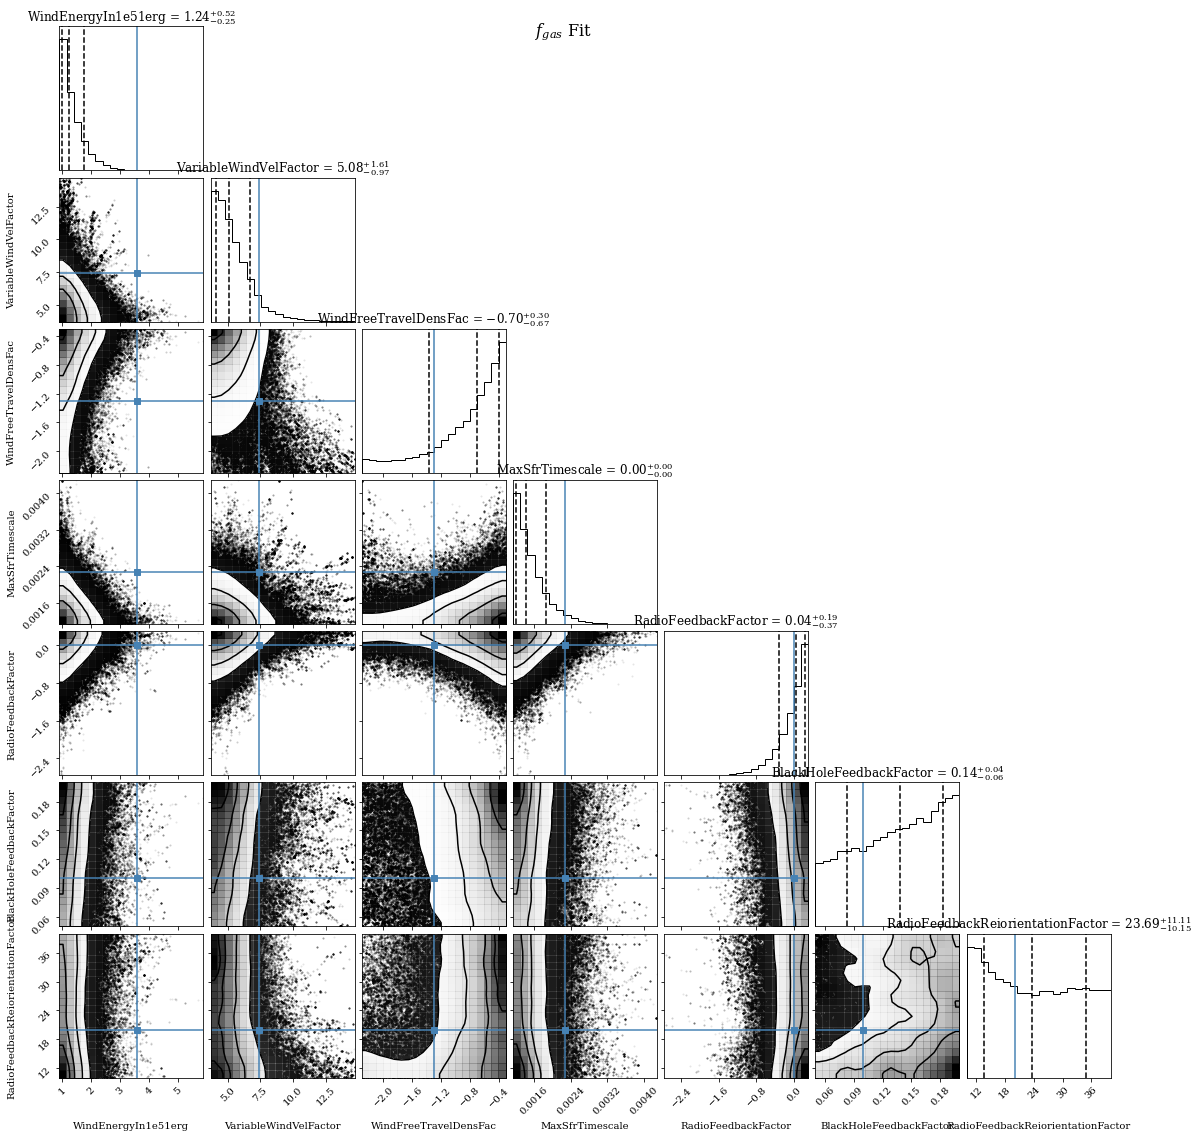


Summary Statistics (Median and 1-sigma uncertainty):
	WindEnergyIn1e51erg = 1.237_{-0.253}^{+0.521}
	VariableWindVelFactor = 5.076_{-0.965}^{+1.613}
	WindFreeTravelDensFac = -0.698_{-0.674}^{+0.298}
	MaxSfrTimescale = 0.001_{-0.000}^{+0.000}
	RadioFeedbackFactor = 0.044_{-0.368}^{+0.192}
	BlackHoleFeedbackFactor = 0.139_{-0.056}^{+0.044}
	RadioFeedbackReiorientationFactor = 23.688_{-10.146}^{+11.105}


In [48]:
# Generate the corner plot 
fig = corner.corner(
    flat_samples, 
    labels=param_names, 
    quantiles=[0.16, 0.5, 0.84], 
    show_titles=True, 
    title_kwargs={"fontsize": 12},
    smooth=True,
    truths = np.asarray([wind_en_or[30], wind_vel_or[30], rho_rec_or[30], sf_ts_or[30], ef_kin_or[30], ef_high_or[30], f_re_or[30]])
)

plt.suptitle("$f_{gas}$ Fit", fontsize=16)
plt.show()

# --- Print Summary Statistics ---
print("\nSummary Statistics (Median and 1-sigma uncertainty):")
for i, name in enumerate(param_names):
    mcmc = np.percentile(flat_samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    txt = "\t{0} = {1:.3f}_{{-{2:.3f}}}^{{+{3:.3f}}}"
    txt = txt.format(name, mcmc[1], q[0], q[1])
    print(txt)

In [40]:
# Assuming 'prepare_theta', 'mass_bins', 'means', and 'stds' are defined in the global scope 
# as in the previous, corrected response.

def get_gp_prediction(theta_original, mstar, gp_model):
    """
    Takes a set of 7 parameters (in original physical units) and returns 
    the predicted GP mean and variance for the full SMF curve (across all mstar bins).
    """
    
    # 1. Standardize theta (using the globally defined prepare_theta function)
    theta_standardized = prepare_theta(theta_original)
    
    # 2. Construct 8D input vector (mstar and standardized theta)
    N_mass_bins = len(mstar)
    theta_vector = np.repeat(theta_standardized[np.newaxis, :], N_mass_bins, axis=0)
    
    # Full 8D input: [log10(M*), theta_1_std, ..., theta_7_std]
    gp_input = np.hstack([
        mstar[:, np.newaxis], # (N_mass_bins, 1)
        theta_vector          # (N_mass_bins, 7)
    ]) 

    # 3. Predict with gpytorch
    x_star = torch.from_numpy(gp_input).float() 
    
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        predictive_dist = gp_model(x_star) 
        
    mu_pred = predictive_dist.mean.numpy()         # Predicted mean SMF curve
    var_emulator = predictive_dist.variance.numpy() # GP intrinsic variance
    
    return mu_pred, var_emulator

In [41]:
def plot_best_fit_smf(flat_samples, m500, obs_fgas, obs_uncertainty, gp_model):
    """
    Plots the observed Stellar-Mass Function along with the MCMC best-fit 
    prediction and associated uncertainties.
    """
    
    # 1. Identify the Best-Fit Parameters (Median of the posterior)
    best_fit_theta = np.median(flat_samples, axis=0)
    
    # 2. Get the Prediction for the Best-Fit Parameters
    mu_pred, var_emulator = get_gp_prediction(best_fit_theta, m500, gp_model)

    # 2. Changing each of the 7 parameters at a time

    
    we_mu_pred, we_var_emulator = get_gp_prediction(best_fit_theta, m500, gp_model)

    # 3. Calculate Uncertainties
    
    # a. Uncertainty from the GP emulator itself (inner shaded region)
    std_emulator = np.sqrt(var_emulator)
        
    # 4. Plotting
    fig, ax = plt.subplots(figsize=(5.5,5), dpi=200)
    
    # A. Plot Observational Data
    ax.errorbar(
        m500, 
        obs_fgas, 
        yerr=obs_uncertainty, # Error bars show the observation uncertainty
        fmt='o', 
        color='k', 
        capsize=3, 
        zorder=3, # Bring to front
        label='Popesso et al (2025)'
    )
        
    # C. Plot Emulator Uncertainty (Inner region, optional but good for diagnostics)
    ax.fill_between(
        m500, 
        mu_pred - std_emulator, 
        mu_pred + std_emulator, 
        color='C0', 
        alpha=0.5, 
        zorder=2,
        label='Emulator $1\sigma$ Uncertainty'
    )
    
    # D. Plot Best-Fit Mean Curve
    ax.plot(
        m500, 
        mu_pred, 
        '-', 
        color='C0', 
        linewidth=3, 
        zorder=4,
        label='Best-Fit GP Prediction (Median $\\theta$)'
    )

    ax.plot(np.log10(zoom_fgas['fiducial']['m500c'][0]), zoom_fgas['fiducial']['f_gas'][0], label='Fiducial', color='black', linewidth=2)
    
    # E. Formatting
    ax.set_xlabel('$\\log_{10}[M_{500,c}/M_{\odot}]$', fontsize=12)
    ax.set_ylabel('$f_{gas}$', fontsize=12)
    ax.legend(fontsize=6)
    ax.grid(True, linestyle='--', alpha=0.6)
    plt.show()

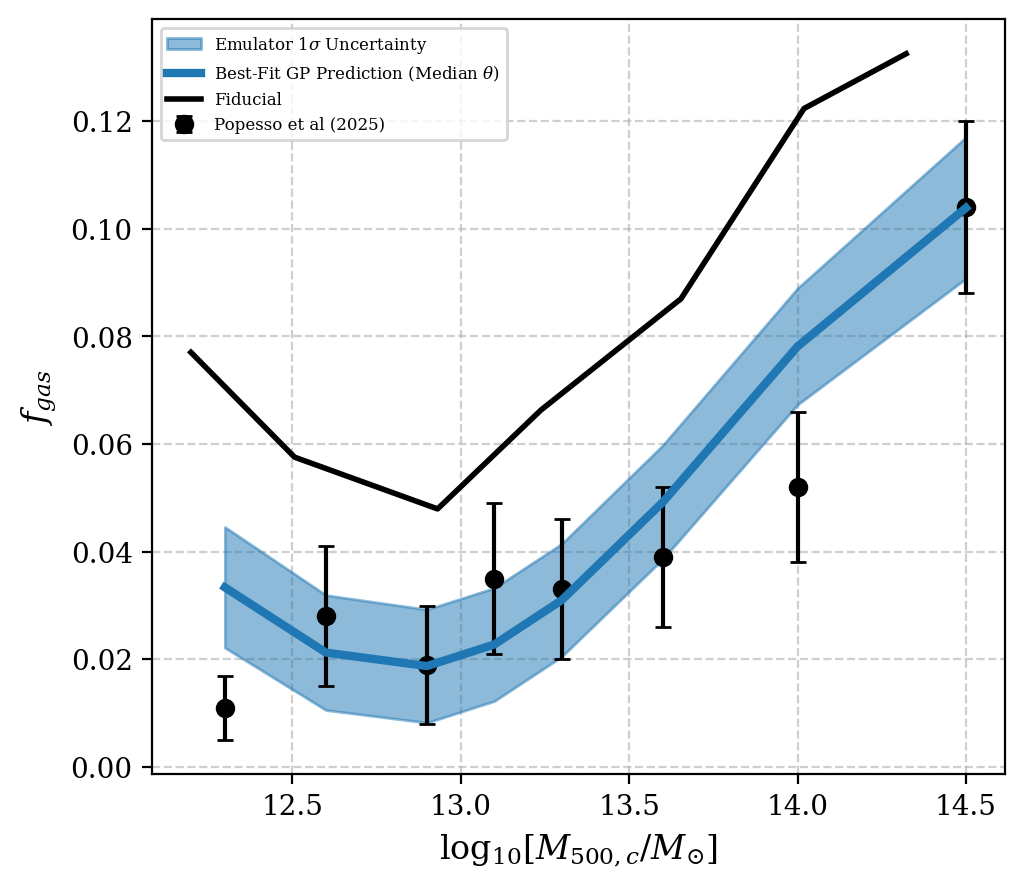

In [42]:
plot_best_fit_smf(
    flat_samples, 
    m500_pp, 
    fgas_pp, 
    err_pp, 
    model
)

Text(0.5, 1.0, 'Cumulative changes to Best-Fit Model')

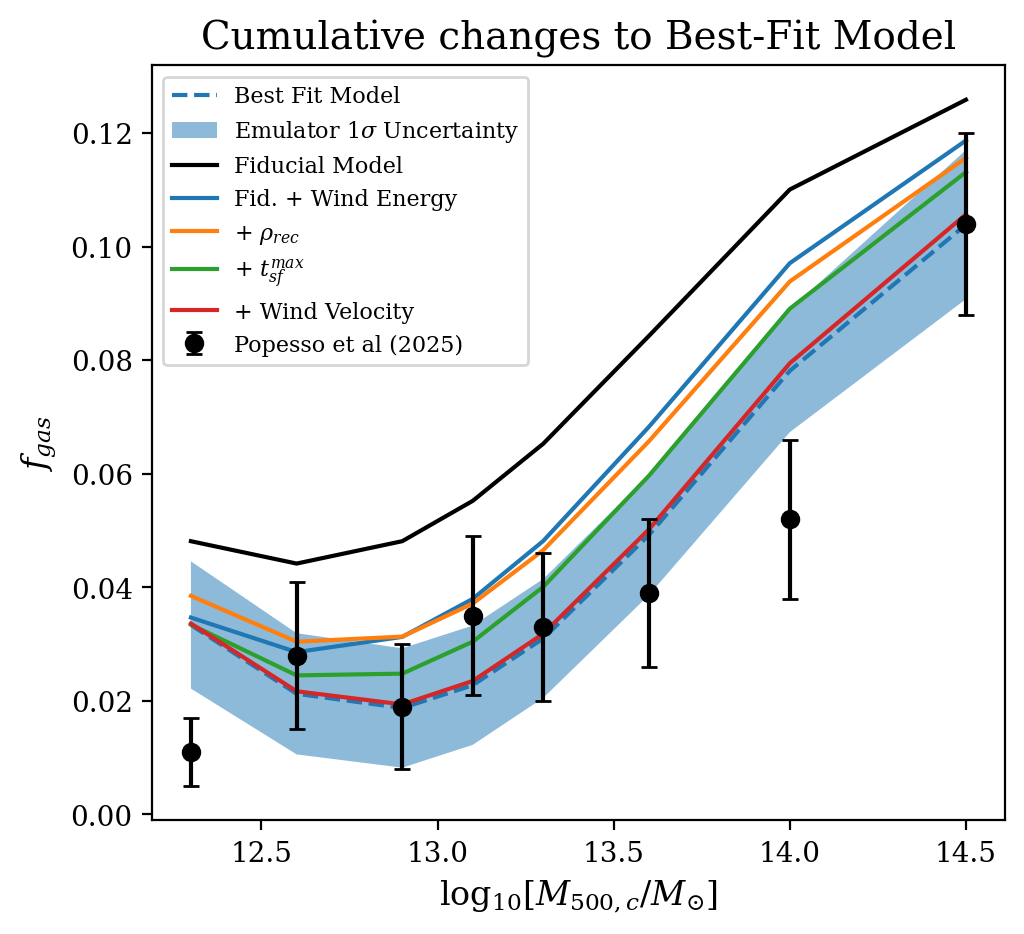

In [50]:
fig, ax = plt.subplots(dpi=200, figsize=(5.5,5))

ax.errorbar(
    m500_pp, 
    fgas_pp, 
    yerr=err_pp, # Error bars show the observation uncertainty
    fmt='o', 
    color='k', 
    capsize=3, 
    zorder=3, # Bring to front
    label='Popesso et al (2025)'
)

# Plot Best-Fit Mean Curve
bf_theta = np.median(flat_samples, axis=0)
mu_pred, var_emulator = get_gp_prediction(bf_theta, m500_pp, model)
ax.plot(m500_pp, mu_pred, ls='--', label='Best Fit Model', color='C0')
ax.fill_between(m500_pp, mu_pred - np.sqrt(var_emulator), mu_pred + np.sqrt(var_emulator), 
    color='C0', alpha=0.5, zorder=2, label='Emulator $1\sigma$ Uncertainty', ec=None)

cmap = plt.get_cmap('copper')

# Plot fiducial model
fid_mu_pred, fid_var_emulator = get_gp_prediction(fid_theta, m500_pp, model)
ax.plot(m500_pp, fid_mu_pred, label='Fiducial Model', color='k')
# ax.plot(np.log10(zoom_fgas['fiducial']['m500c'][0]), zoom_fgas['fiducial']['f_gas'][0], label='Fiducial', color='black', linewidth=2)

ch_theta = np.copy(fid_theta)
# Wind Energy
ch_theta[0] = bf_theta[0]
ch_mu_pred, ch_var_emulator = get_gp_prediction(ch_theta, m500_pp, model)
ax.plot(m500_pp, ch_mu_pred, color='C0', label='Fid. + Wind Energy')

# Reincorporation Density
ch_theta[2] = bf_theta[2]
ch_mu_pred, ch_var_emulator = get_gp_prediction(ch_theta, m500_pp, model)
ax.plot(m500_pp, ch_mu_pred, color='C1', label='+ $\\rho_{rec}$')

# Timescale of Star-Formation
ch_theta[3] = bf_theta[3]
ch_mu_pred, ch_var_emulator = get_gp_prediction(ch_theta, m500_pp, model)
ax.plot(m500_pp, ch_mu_pred, color='C2', label='+ $t_{sf}^{max}$')

# Wind Velocity
ch_theta[1] = bf_theta[1]
ch_mu_pred, ch_var_emulator = get_gp_prediction(ch_theta, m500_pp, model)
ax.plot(m500_pp, ch_mu_pred, color='C3', label='+ Wind Velocity')

ax.set_xlabel('$\\log_{10}[M_{500,c}/M_{\odot}]$', fontsize=12)
ax.set_ylabel('$f_{gas}$', fontsize=12)
ax.legend(fontsize=8)

ax.set_title("Cumulative changes to Best-Fit Model", fontsize=14)


Text(0.5, 1.0, 'One parameter changes to Best-Fit Model')

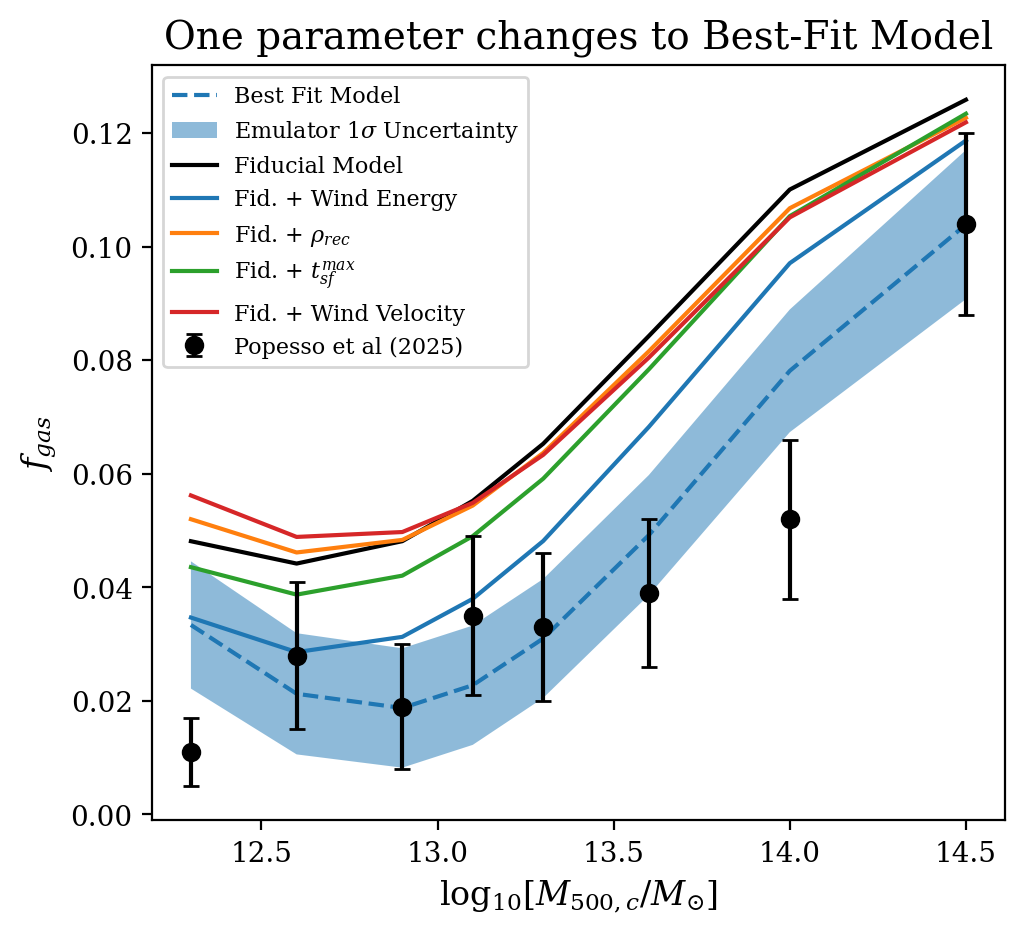

In [52]:
fig, ax = plt.subplots(dpi=200, figsize=(5.5,5))

ax.errorbar(
    m500_pp, 
    fgas_pp, 
    yerr=err_pp, # Error bars show the observation uncertainty
    fmt='o', 
    color='k', 
    capsize=3, 
    zorder=3, # Bring to front
    label='Popesso et al (2025)'
)

# Plot Best-Fit Mean Curve
bf_theta = np.median(flat_samples, axis=0)
mu_pred, var_emulator = get_gp_prediction(bf_theta, m500_pp, model)
ax.plot(m500_pp, mu_pred, ls='--', label='Best Fit Model', color='C0')
ax.fill_between(m500_pp, mu_pred - np.sqrt(var_emulator), mu_pred + np.sqrt(var_emulator), 
    color='C0', alpha=0.5, zorder=2, label='Emulator $1\sigma$ Uncertainty', ec=None)

cmap = plt.get_cmap('copper')

# Plot fiducial model
fid_theta = np.asarray([wind_en_or[30], wind_vel_or[30], rho_rec_or[30], sf_ts_or[30], ef_kin_or[30], ef_high_or[30], f_re_or[30]])
fid_mu_pred, fid_var_emulator = get_gp_prediction(fid_theta, m500_pp, model)
ax.plot(m500_pp, fid_mu_pred, label='Fiducial Model', color='k')
# ax.plot(np.log10(zoom_fgas['fiducial']['m500c'][0]), zoom_fgas['fiducial']['f_gas'][0], label='Fiducial', color='black', linewidth=2)

ch_theta = np.copy(fid_theta)
# Wind Energy
ch_theta[0] = bf_theta[0]
ch_mu_pred, ch_var_emulator = get_gp_prediction(ch_theta, m500_pp, model)
ax.plot(m500_pp, ch_mu_pred, color='C0', label='Fid. + Wind Energy')

ch_theta = np.copy(fid_theta)
# Reincorporation Density
ch_theta[2] = bf_theta[2]
ch_mu_pred, ch_var_emulator = get_gp_prediction(ch_theta, m500_pp, model)
ax.plot(m500_pp, ch_mu_pred, color='C1', label='Fid. + $\\rho_{rec}$')

ch_theta = np.copy(fid_theta)
# Timescale of Star-Formation
ch_theta[3] = bf_theta[3]
ch_mu_pred, ch_var_emulator = get_gp_prediction(ch_theta, m500_pp, model)
ax.plot(m500_pp, ch_mu_pred, color='C2', label='Fid. + $t_{sf}^{max}$')

ch_theta = np.copy(fid_theta)
# Wind Velocity
ch_theta[1] = bf_theta[1]
ch_mu_pred, ch_var_emulator = get_gp_prediction(ch_theta, m500_pp, model)
ax.plot(m500_pp, ch_mu_pred, color='C3', label='Fid. + Wind Velocity')

ax.set_xlabel('$\\log_{10}[M_{500,c}/M_{\odot}]$', fontsize=12)
ax.set_ylabel('$f_{gas}$', fontsize=12)
ax.legend(fontsize=8)

ax.set_title("One parameter changes to Best-Fit Model", fontsize=14)

In [45]:
bf_sigma = np.std(flat_samples, axis=0)

dist_bf = np.zeros(31)
for i in range(31):
    diff_sigma = (bf_theta - np.asarray([wind_en_or[i], wind_vel_or[i], rho_rec_or[i], sf_ts_or[i], ef_kin_or[i], ef_high_or[i], f_re_or[i]])) / bf_sigma
    dist_bf[i] = np.sqrt( np.sum(diff_sigma**2) )

Text(0.5, 1.0, 'Cumulative changes to Best-Fit Model')

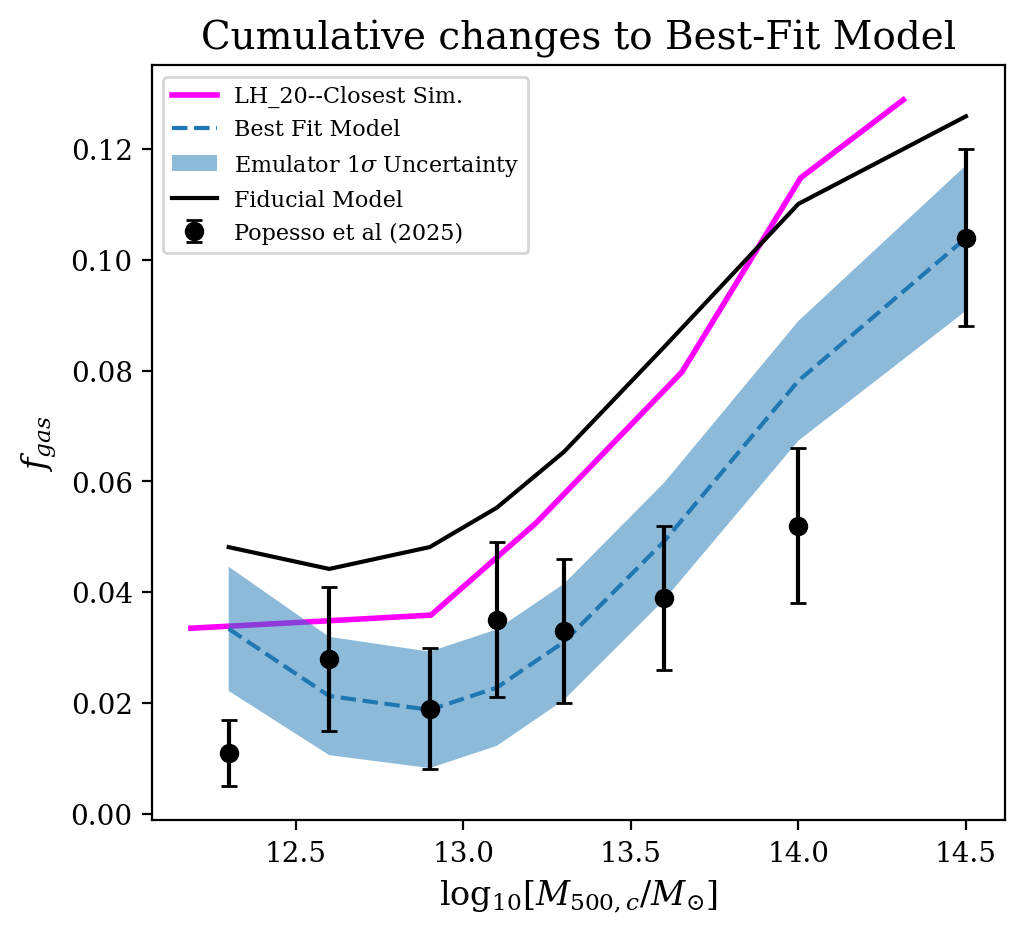

In [46]:
fig, ax = plt.subplots(dpi=200, figsize=(5.5,5))

ax.errorbar(
    m500_pp, 
    fgas_pp, 
    yerr=err_pp, # Error bars show the observation uncertainty
    fmt='o', 
    color='k', 
    capsize=3, 
    zorder=3, # Bring to front
    label='Popesso et al (2025)'
)

sim_name = 'LH_{:d}'.format(np.argmin(dist_bf))
ax.plot(np.log10(zoom_fgas[sim_name]['m500c'][0]), zoom_fgas[sim_name]['f_gas'][0], label=sim_name+"--Closest Sim.", color='magenta', linewidth=2)

# Plot Best-Fit Mean Curve
bf_theta = np.median(flat_samples, axis=0)
mu_pred, var_emulator = get_gp_prediction(bf_theta, m500_pp, model)
ax.plot(m500_pp, mu_pred, ls='--', label='Best Fit Model', color='C0')
ax.fill_between(m500_pp, mu_pred - np.sqrt(var_emulator), mu_pred + np.sqrt(var_emulator), 
    color='C0', alpha=0.5, zorder=2, label='Emulator $1\sigma$ Uncertainty', ec=None)

cmap = plt.get_cmap('copper')

# Plot fiducial model
fid_mu_pred, fid_var_emulator = get_gp_prediction(fid_theta, m500_pp, model)
ax.plot(m500_pp, fid_mu_pred, label='Fiducial Model', color='k')
# ax.plot(np.log10(zoom_fgas['fiducial']['m500c'][0]), zoom_fgas['fiducial']['f_gas'][0], label='Fiducial', color='black', linewidth=2)

ax.set_xlabel('$\\log_{10}[M_{500,c}/M_{\odot}]$', fontsize=12)
ax.set_ylabel('$f_{gas}$', fontsize=12)
ax.legend(fontsize=8)

ax.set_title("Cumulative changes to Best-Fit Model", fontsize=14)


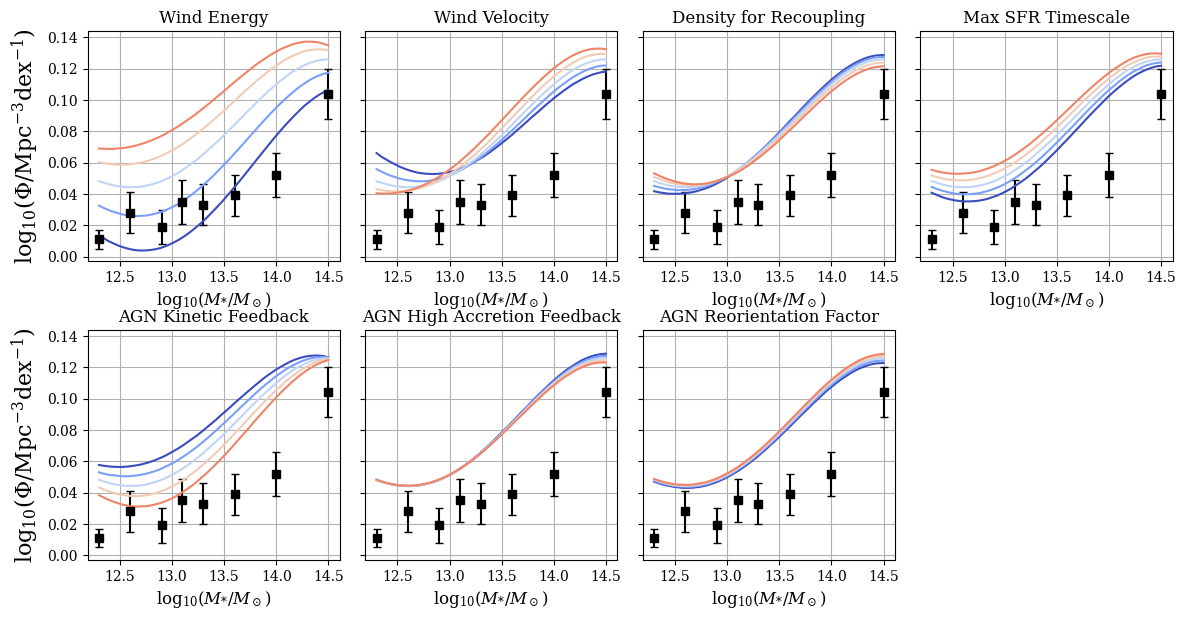

In [79]:
fig, ax = plt.subplots(2,4, dpi=100, sharey=True, figsize=(14,7))

ax[0,0].set_ylabel('$\\log_{10}(\\Phi / \\mathrm{Mpc}^{-3}\mathrm{dex}^{-1})$', fontsize=16)
ax[1,0].set_ylabel('$\\log_{10}(\\Phi / \\mathrm{Mpc}^{-3}\mathrm{dex}^{-1})$', fontsize=16)

cmap = plt.get_cmap('coolwarm')

mstar_test = np.linspace(12.3,14.5,50)
names = ['Wind Energy', 'Wind Velocity', 'Density for Recoupling', 'Max SFR Timescale', 'AGN Kinetic Feedback', 'AGN High Accretion Feedback', 'AGN Reorientation Factor']

mu_fid, var_fid = get_gp_prediction(fid_theta, mstar_test, model)

for j in range(7):
    ix = j//4
    jx = j%4

    ax[ix,jx].set_title(names[j], fontsize=12)
    ax[ix,jx].set_xlabel(r"$\log_{10}(M_{*}/M_\odot)$", fontsize=12)
    theta_vars = get_theta_1p_vars(j, 5)

    ax[ix,jx].errorbar(m500_pp, fgas_pp, yerr=err_pp, label='Popesso et al. 2025', alpha=1, marker='s', capsize=3, ms=6, color='k', ls='')

    for i in range(5):
        # Our measurements
        mu_pred, var = get_gp_prediction(theta_vars[i], mstar_test, model)
        ax[ix,jx].plot(mstar_test, mu_pred, color=cmap(i/5))
    
    ax[ix,jx].grid()

ax[1,3].axis('off')

plt.subplots_adjust(wspace=0.1, hspace=0.3)